<a href="https://colab.research.google.com/github/abdulbaseer53078-wq/abdulbaseer53078-wq/blob/main/Copy_of_Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
ticker = 'AAPL'
df = yf.download(ticker, '2020-01-01')

/tmp/ipykernel_2679/2867026071.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, '2020-01-01')
[*********************100%***********************]  1 of 1 completed


In [ ]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928040,72.533080,71.708680,72.277563,108872000
2020-01-08,73.085091,73.386408,71.631537,71.631537,132079200
...,...,...,...,...,...
2026-03-31,253.789993,255.479996,247.100006,247.910004,49598100
2026-04-01,255.630005,256.179993,253.330002,254.080002,40059400


<Axes: xlabel='Date'>

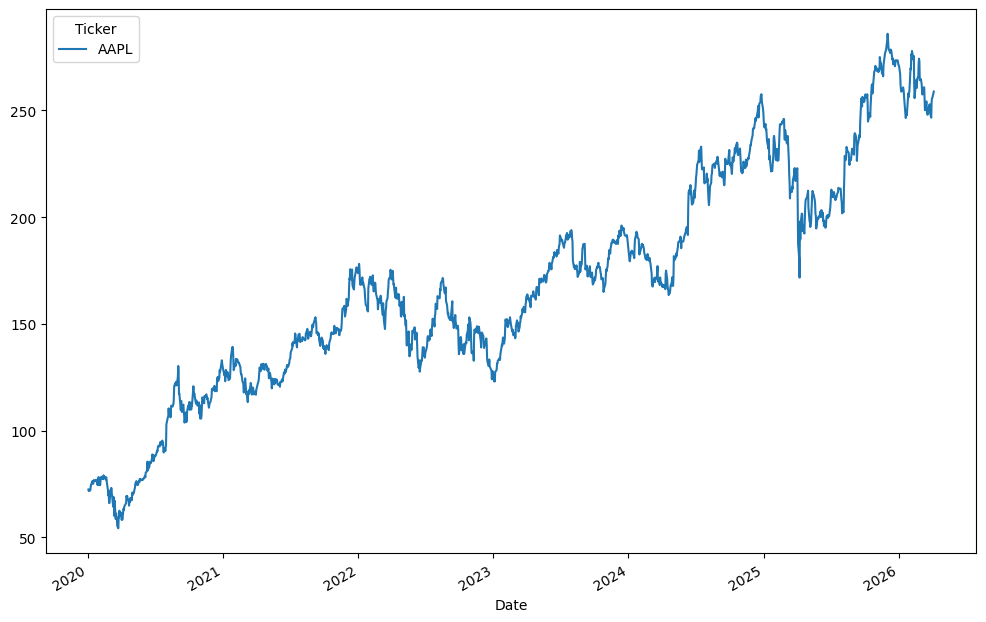

In [ ]:
df.Close.plot(figsize=(12, 8))

In [ ]:
scaler = StandardScaler()
df ['Close'] = scaler.fit_transform(df['Close'])

In [ ]:
df.Close

Ticker,AAPL
Date,
2020-01-02,-1.845039
2020-01-03,-1.858530
2020-01-06,-1.847580
2020-01-07,-1.854095
2020-01-08,-1.831918
...,...
2026-03-31,1.631588
2026-04-01,1.666855
2026-04-02,1.672413


In [ ]:
seq_length = 30
data = []
for i in range(len(df) - seq_length):
  data.append(df.Close[i:i+seq_length])

data = np.array(data)

In [ ]:
data

array([[[-1.84503909],
        [-1.85853011],
        [-1.84758027],
        ...,
        [-1.75254985],
        [-1.71739925],
        [-1.72818999]],

       [[-1.85853011],
        [-1.84758027],
        [-1.8540951 ],
        ...,
        [-1.71739925],
        [-1.72818999],
        [-1.72781945]],

       [[-1.84758027],
        [-1.8540951 ],
        [-1.83191832],
        ...,
        [-1.72818999],
        [-1.72781945],
        [-1.75537486]],

       ...,

       [[ 1.76172973],
        [ 1.83839631],
        [ 1.86906306],
        ...,
        [ 1.49435539],
        [ 1.63158834],
        [ 1.66685519]],

       [[ 1.83839631],
        [ 1.86906306],
        [ 1.98329668],
        ...,
        [ 1.63158834],
        [ 1.66685519],
        [ 1.67241339]],

       [[ 1.86906306],
        [ 1.98329668],
        [ 2.0233549 ],
        ...,
        [ 1.66685519],
        [ 1.67241339],
        [ 1.72876308]]])

In [ ]:
train_size = int(0.8* len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [ ]:
class PredictionModel(nn.Module):
  def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
    super(PredictionModel, self).__init__()
    self.num_layers = num_layers
    self.hidden_dim = hidden_dim

    self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_dim, output_dim)

  def forward(self, x):
    ho = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
    co = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
    out, (hn, cn) = self.lstm(x, (ho.detach(), co.detach()))
    out = self.fc(out[:, -1, :])
    return out

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class PredictionModel(nn.Module):
  def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
    super(PredictionModel, self).__init__()
    self.num_layers = num_layers
    self.hidden_dim = hidden_dim
    self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_dim, output_dim)

  def forward(self, x):
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
    c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
    out, _ = self.lstm(x, (h0.detach(), c0.detach()))
    out = self.fc(out[:, -1, :])
    return out

# Re-initializing model with higher capacity for better accuracy
model = PredictionModel(input_dim=1, hidden_dim=128, num_layers=2, output_dim=1).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(f'Model initialized on {device}. Ready for training.')

Model initialized on cpu. Ready for training.


In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 300

# Training Loop
# Ensure X_train and y_train are defined by running previous cells first
try:
  model.train()
  for i in range(num_epochs):
    optimizer.zero_grad()

    # Forward pass
    y_train_pred = model(X_train)

    loss = criterion(y_train_pred, y_train)
    loss.backward()
    optimizer.step()

    if i % 25 == 0:
      print(f'Epoch {i}, Loss: {loss.item():.6f}')

  print('Training complete. You can now run the evaluation cell.')
except NameError as e:
  print(f'Error: {e}. Please ensure you have executed the data preparation cell (cell_id: ZB4eSRdmmHx3) before training.')

Epoch 0, Loss: 0.671743
Epoch 25, Loss: 0.029646
Epoch 50, Loss: 0.012025
Epoch 75, Loss: 0.009094
Epoch 100, Loss: 0.008397
Epoch 125, Loss: 0.007865
Epoch 150, Loss: 0.007397
Epoch 175, Loss: 0.007008
Epoch 200, Loss: 0.006666
Epoch 225, Loss: 0.006364
Epoch 250, Loss: 0.006095


In [ ]:
model.eval()

# Get fresh predictions from the model (these are PyTorch tensors)
y_train_pred_tensor = model(X_train)
y_test_pred_tensor = model(X_test)

# Inverse transform the predictions
y_train_pred = scaler.inverse_transform(y_train_pred_tensor.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred_tensor.detach().cpu().numpy())

# Inverse transform the actual values
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())

In [ ]:
train_rmse = np.sqrt(mean_squared_error(y_train[:, 0], y_train_pred[:, 0]))
test_rmse = np.sqrt(mean_squared_error(y_test[:, 0], y_test_pred[:, 0]))

In [ ]:
train_rmse

In [ ]:
test_rmse

In [ ]:
fig = plt.figure(figsize=(12, 10))

gs = fig.add_gridspec (4, 1)

ax1 = fig.add_subplot(gs[:3,0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color='blue', label='Actual Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color='green', label='Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel('Date')
plt.ylabel('Price')

ax2 = fig.add_subplot(gs [3, 0])
ax2.axhline(test_rmse, color='blue', linestyle='--', label='RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label='Prediction Error')
ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.xlabel('Date')
plt.ylabel('Error')

plt.tight_layout()
plt.show()